In [1]:
import os
import ast
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

csv_path = "../data/dataset_full.csv"

# Dataset Inspection & Visualization
These cells are optimized for a very large CSV by using sampled reads and chunk-friendly patterns.

In [2]:
# Quick file-level context (without full load)
file_size_mb = os.path.getsize(csv_path) / (1024 ** 2)
with open(csv_path, "r", encoding="utf-8", errors="ignore") as f:
    header = f.readline().strip().split(',')

print(f"File size: {file_size_mb:,.2f} MB")
print(f"Columns ({len(header)}): {header}")

File size: 2,188.66 MB
Columns (7): ['', 'title', 'ingredients', 'directions', 'link', 'source', 'NER']


In [3]:
# Shape, schema, and memory footprint of current working sample
df = pd.read_csv(csv_path, low_memory=False)
print("Sample shape:", df.shape)
display(df.dtypes.to_frame("dtype"))

memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Approx sample memory usage: {memory_mb:,.2f} MB")
df.head(3)

Sample shape: (2231142, 7)


,dtype
Unnamed: 0,int64
title,str
ingredients,str
directions,str
link,str
source,str
NER,str


Approx sample memory usage: 2,688.52 MB


,Unnamed: 0,title,ingredients,directions,link,source,NER
0,0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. evaporated milk"", ""1/2 tsp. vanilla"", ""1/2 c. broken nuts (pecans)"", ""2 T...","[""In a heavy 2-quart saucepan, mix brown sugar, nuts, evaporated milk and butter or margarine."", ""Stir over medium h...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""butter"", ""bite size shredded rice biscuits""]"
1,1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned chicken breasts"", ""1 can cream of mushroom soup"", ""1 carton sour cream""]","[""Place chipped beef on bottom of baking dish."", ""Place chicken on top of beef."", ""Mix soup and cream together; pour...",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom soup"", ""sour cream""]"
2,2,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg. cream cheese, cubed"", ""1/3 c. butter, cubed"", ""1/2 tsp. garlic powde...","[""In a slow cooker, combine all ingredients. Cover and cook on low for 4 hours or until heated through and cheese is...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""cream cheese"", ""butter"", ""garlic powder"", ""salt"", ""pepper""]"


In [4]:
# Missingness and duplicate diagnostics
missing = df.isna().sum().sort_values(ascending=False).to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
display(missing)

dup_rows = df.duplicated().sum()
print(f"Duplicate rows in sample: {dup_rows:,} ({dup_rows / len(df) * 100:.2f}%)")

,missing_count,missing_pct
title,1,0.0
Unnamed: 0,0,0.0
ingredients,0,0.0
directions,0,0.0
link,0,0.0
source,0,0.0
NER,0,0.0


Duplicate rows in sample: 0 (0.00%)


/var/folders/hj/0g8xmk093_d0chf2nqjgcn7m0000gn/T/ipykernel_67265/1123996401.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=source_counts.values, y=source_counts.index, orient="h", palette="viridis")


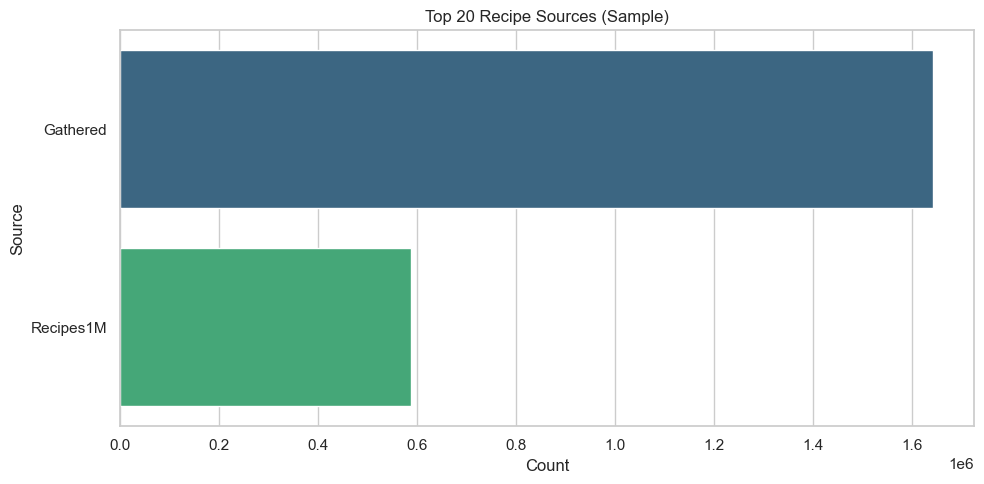

In [5]:
# Distribution of recipe sources
source_counts = df["source"].fillna("<missing>").value_counts().head(20)
plt.figure(figsize=(10, 5))
sns.barplot(x=source_counts.values, y=source_counts.index, orient="h", palette="viridis")
plt.title("Top 20 Recipe Sources (Sample)")
plt.xlabel("Count")
plt.ylabel("Source")
plt.tight_layout()
plt.show()

In [6]:
# Length-based text features
for col in ["title", "ingredients", "directions", "NER"]:
    df[f"{col}_char_len"] = df[col].fillna("").astype(str).str.len()

len_cols = ["title_char_len", "ingredients_char_len", "directions_char_len", "NER_char_len"]
display(df[len_cols].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).T)

,count,mean,std,min,10%,25%,50%,75%,90%,99%,max
title_char_len,2231142.0,23.903333,11.461224,0.0,12.0,16.0,21.0,29.0,39.0,62.0,310.0
ingredients_char_len,2231142.0,258.943957,145.703726,5.0,115.0,159.0,225.0,324.0,446.0,748.0,11018.0
directions_char_len,2231142.0,505.109928,452.409335,5.0,134.0,221.0,371.0,641.0,1033.0,2184.0,14979.0
NER_char_len,2231142.0,111.746274,55.010595,2.0,54.0,74.0,102.0,138.0,181.0,290.0,5597.0


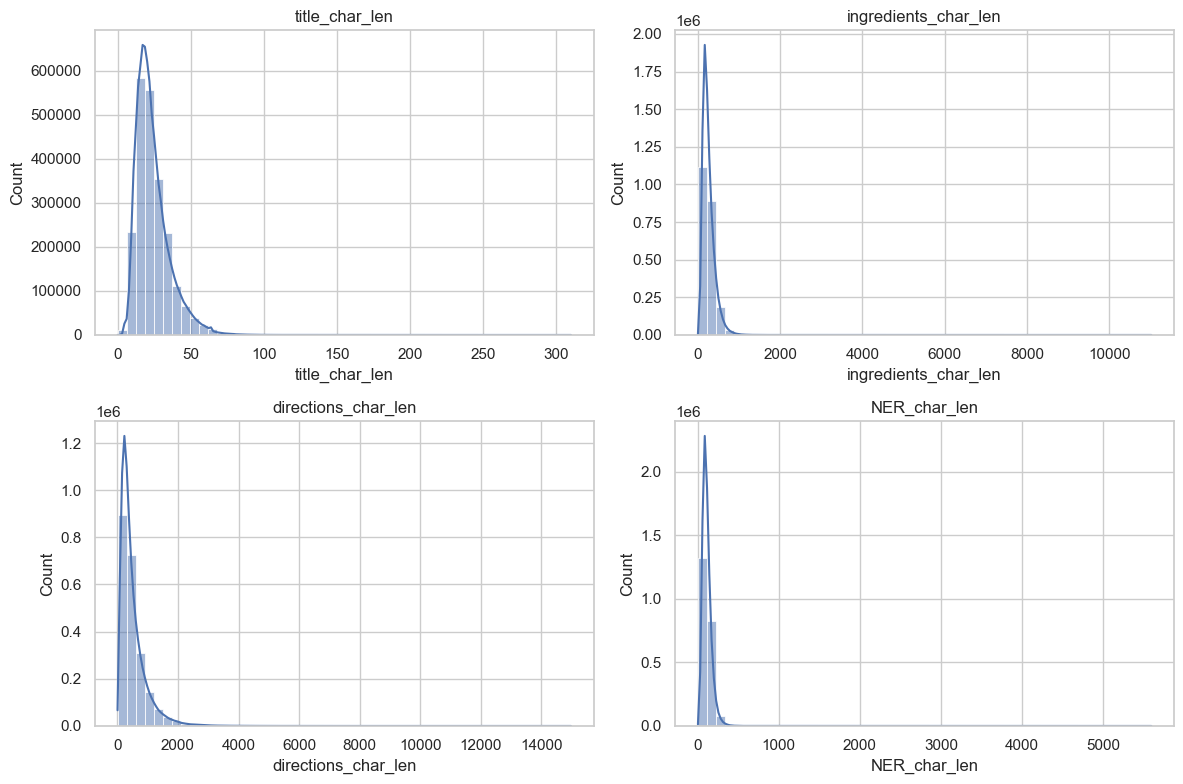

In [7]:
# Histograms for text lengths
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
len_cols = ["title_char_len", "ingredients_char_len", "directions_char_len", "NER_char_len"]

for ax, col in zip(axes, len_cols):
    sns.histplot(df[col], bins=50, ax=ax, kde=True)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [8]:
# Robust parser for list-like columns stored as strings
def safe_parse_list(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    text = str(value).strip()
    if not text:
        return []
    try:
        parsed = ast.literal_eval(text)
        return parsed if isinstance(parsed, list) else []
    except Exception:
        return []

for col in ["ingredients", "directions", "NER"]:
    df[f"{col}_list"] = df[col].apply(safe_parse_list)
    df[f"{col}_count"] = df[f"{col}_list"].str.len()

df[["ingredients_count", "directions_count", "NER_count"]].head()

,ingredients_count,directions_count,NER_count
0,6,6,6
1,4,3,4
2,6,1,6
3,5,6,4
4,5,3,5


In [9]:
# Unique ingredient count (from parsed ingredient lists)
ingredient_tokens = (
    df["ingredients_list"]
    .explode()
    .dropna()
    .astype(str)
    .str.strip()
    .str.lower()
    .replace("", pd.NA)
    .dropna()
 )

unique_ingredient_count = ingredient_tokens.nunique()
print(f"Unique ingredients (sample): {unique_ingredient_count:,}")

Unique ingredients (sample): 4,472,031


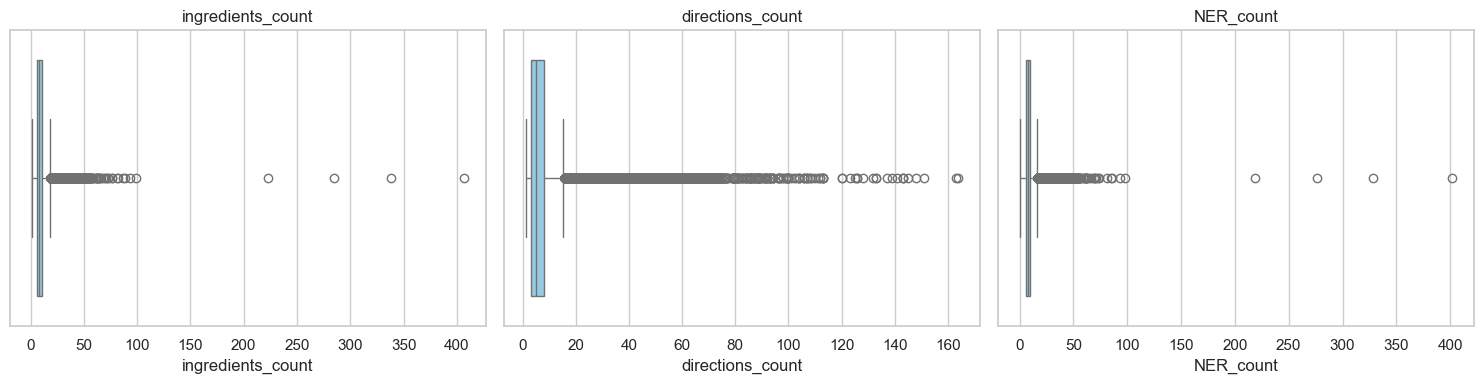

In [10]:
# Distribution of list counts
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["ingredients_count", "directions_count", "NER_count"]):
    sns.boxplot(x=df[col], ax=ax, color="#89CFF0")
    ax.set_title(col)

plt.tight_layout()
plt.show()

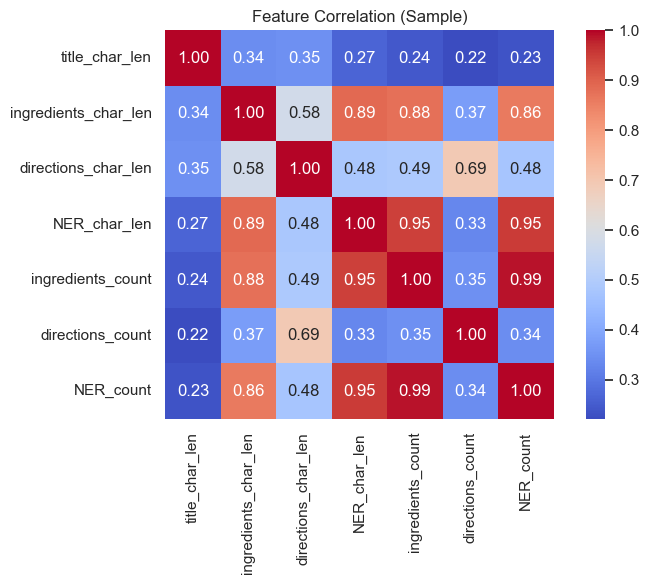

In [11]:
# Correlation heatmap for engineered numeric features
numeric_cols = [
    "title_char_len", "ingredients_char_len", "directions_char_len", "NER_char_len",
    "ingredients_count", "directions_count", "NER_count"
]
corr = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation (Sample)")
plt.tight_layout()
plt.show()

,count
ingredients_list,
2 eggs,98618
1 tsp. vanilla,85584
1 egg,81308
1/2 tsp. salt,80956
1 tsp. salt,80665
1/2 teaspoon salt,71039
1 teaspoon salt,69676
1 c. sugar,65849
salt and pepper,54835


/var/folders/hj/0g8xmk093_d0chf2nqjgcn7m0000gn/T/ipykernel_67265/988787273.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ingredients.values, y=top_ingredients.index, orient="h", palette="mako")


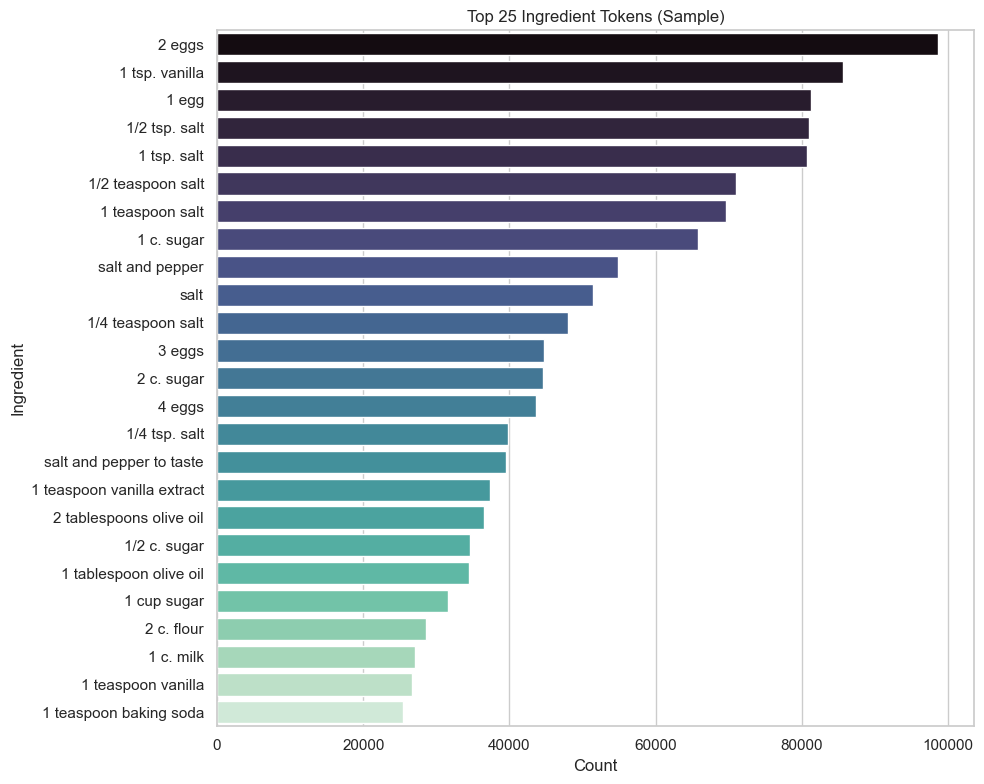

In [12]:
# Most common ingredients from parsed ingredient lists
ingredient_tokens = (
    df["ingredients_list"]
    .explode()
    .dropna()
    .astype(str)
    .str.strip()
    .str.lower()
    .replace("", np.nan)
    .dropna()
)

top_ingredients = ingredient_tokens.value_counts().head(25)
display(top_ingredients.to_frame("count"))

plt.figure(figsize=(10, 8))
sns.barplot(x=top_ingredients.values, y=top_ingredients.index, orient="h", palette="mako")
plt.title("Top 25 Ingredient Tokens (Sample)")
plt.xlabel("Count")
plt.ylabel("Ingredient")
plt.tight_layout()
plt.show()

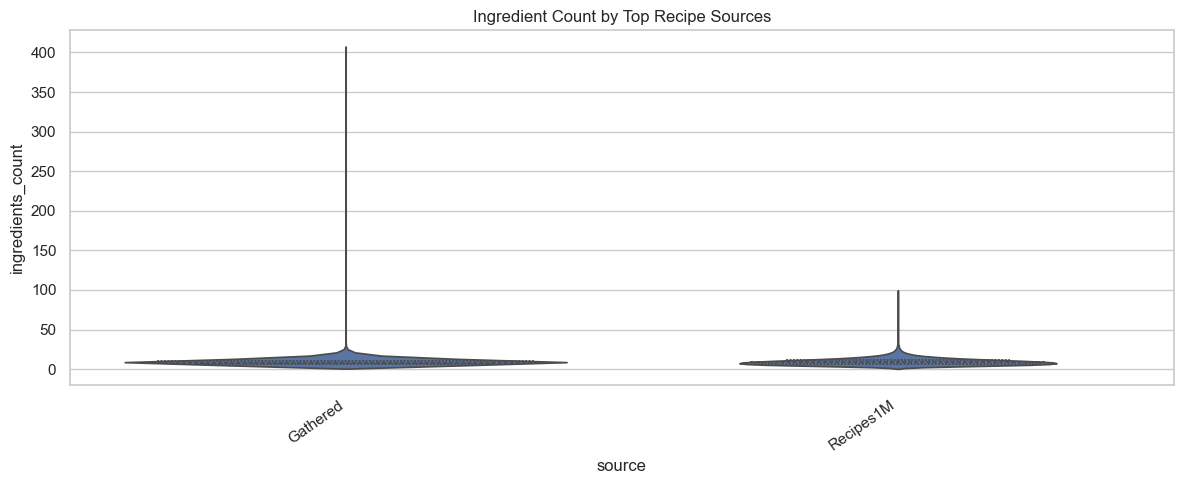

In [13]:
# Compare ingredient count distribution across top sources
top_sources = df["source"].value_counts().head(8).index
plot_df = df[df["source"].isin(top_sources)].copy()

plt.figure(figsize=(12, 5))
sns.violinplot(data=plot_df, x="source", y="ingredients_count", inner="quartile")
plt.xticks(rotation=35, ha="right")
plt.title("Ingredient Count by Top Recipe Sources")
plt.tight_layout()
plt.show()

In [14]:
# Chunk-based global row and missingness stats (memory safe)
chunk_size = 200000
total_rows = 0
missing_by_col = None

for chunk in pd.read_csv(csv_path, chunksize=chunk_size, low_memory=False):
    total_rows += len(chunk)
    chunk_missing = chunk.isna().sum()
    if missing_by_col is None:
        missing_by_col = chunk_missing
    else:
        missing_by_col = missing_by_col.add(chunk_missing, fill_value=0)

missing_global = pd.DataFrame({
    "missing_count": missing_by_col.astype(int),
    "missing_pct": (missing_by_col / total_rows * 100).round(2)
}).sort_values("missing_count", ascending=False)

print(f"Estimated total rows (excluding header): {total_rows:,}")
display(missing_global)

Estimated total rows (excluding header): 2,231,142


,missing_count,missing_pct
title,1,0.0
Unnamed: 0,0,0.0
ingredients,0,0.0
directions,0,0.0
link,0,0.0
source,0,0.0
NER,0,0.0


In [15]:
# Optional: build a random sample from chunks for larger-scale visual checks
def sample_from_chunks(path, chunksize=200000, frac=0.01, seed=42):
    rng = np.random.default_rng(seed)
    sampled_chunks = []
    for chunk in pd.read_csv(path, chunksize=chunksize, low_memory=False):
        if len(chunk) == 0:
            continue
        rs = int(rng.integers(0, 1_000_000_000))
        sampled_chunks.append(chunk.sample(frac=frac, random_state=rs))
    if not sampled_chunks:
        return pd.DataFrame()
    return pd.concat(sampled_chunks, ignore_index=True)

# Example usage (uncomment to run):
# df_chunk_sample = sample_from_chunks(csv_path, frac=0.005)
# df_chunk_sample.shape